# Mastering Imperfect Information with Deep Recurrent Q-Networks
## Leduc Hold'em — DRQN vs DQN vs Heuristic vs Random

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/DLPW/blob/master/notebooks/DLPW_colab.ipynb)

**Google Colab Version**

**Runtime**: GPU recommended (Runtime → Change runtime type → GPU)

## 1. Install Dependencies

In [1]:
!pip install -q rlcard

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Dependencies installed")
print(f"✓ Device: {device}")
print(f"✓ PyTorch version: {torch.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 23.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ Dependencies installed
✓ Device: cuda
✓ PyTorch version: 2.10.0+cu128


## 2. Setup Project Files

Choose one option below:

### Option A: Clone from GitHub (Recommended)

In [2]:
import os
import sys

# Clone repository
!git clone https://github.com/Aghaei-Amirmasoud/DLPW.git
%cd DLPW

# Add to Python path
sys.path.insert(0, '/content/DLPW')

print("✓ Repository cloned and path configured")

Cloning into 'DLPW'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 38 (delta 6), reused 36 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 265.05 KiB | 26.50 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/DLPW
✓ Repository cloned and path configured


### Option B: Mount Google Drive

In [ ]:
# Uncomment and run if project is in Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
#
# # Update path to your DLPW folder location in Drive
# project_path = '/content/drive/MyDrive/DLPW'
# %cd {project_path}
#
# import sys
# sys.path.insert(0, project_path)
#
# print("✓ Google Drive mounted and path configured")

## 3. Update Config for Colab (Faster Training)

In [3]:
# Override config for faster Colab training
import config

# Reduce episodes for faster training on Colab
config.NUM_EPISODES_PHASE1 = 12000   # Original: 15000
config.NUM_EPISODES_PHASE2 = 13000  # Original: 15000
config.EVALUATE_EVERY = 1000         # Original: 1000
config.EVALUATE_NUM = 1000           # Original: 1000
config.NUM_EVAL_HANDS = 1000        # Original: 3000

# Update output paths for Colab
config.OUTPUT_DIR = '/content/DLPW/outputs'
config.MODEL_DIR = '/content/DLPW/outputs/models'
config.PLOT_DIR = '/content/DLPW/outputs/plots'

# Create directories
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(config.MODEL_DIR, exist_ok=True)
os.makedirs(config.PLOT_DIR, exist_ok=True)

print("✓ Configuration updated for Colab")
print(f"  Phase 1: {config.NUM_EPISODES_PHASE1} episodes")
print(f"  Phase 2: {config.NUM_EPISODES_PHASE2} episodes")
print(f"  Device: {config.DEVICE}")
print(f"  Output: {config.OUTPUT_DIR}")

✓ Configuration updated for Colab
  Phase 1: 12000 episodes
  Phase 2: 13000 episodes
  Device: cuda
  Output: /content/DLPW/outputs


## 4. Import Modules

In [4]:
import rlcard
from rlcard.utils import set_seed
from rlcard.agents import RandomAgent, DQNAgent

from config import *
from agents import DRQNAgent, ConservativeHeuristicAgent
from training import CurriculumTrainer
from evaluation import evaluate_agents, compute_action_distribution
from analysis import plot_training_curves, plot_ev_comparison_bar

print("✓ All modules imported successfully")

✓ All modules imported successfully


## 5. Environment Setup

In [5]:
set_seed(SEED)
env = rlcard.make(ENV_NAME)

raw_shape = env.state_shape[0]
state_shape = raw_shape[0] if isinstance(raw_shape, list) else raw_shape
num_actions = env.num_actions

print(f'✓ Environment: {ENV_NAME}')
print(f'✓ State shape: {state_shape} | Num actions: {num_actions}')
print(f'✓ Device: {DEVICE}')

✓ Environment: leduc-holdem
✓ State shape: 36 | Num actions: 4
✓ Device: cuda


## 6. Initialize Agents

In [6]:
# DRQN Agent (with LSTM memory)
agent_drqn = DRQNAgent(
    state_shape=state_shape,
    num_actions=num_actions,
    device=DEVICE,
    hidden_size=HIDDEN_SIZE,
    lr=LEARNING_RATE,
    gamma=GAMMA,
    epsilon_start=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    buffer_capacity=BUFFER_CAPACITY,
    batch_size=BATCH_SIZE,
    min_replay=MIN_REPLAY_SIZE,
    target_update_freq=TARGET_UPDATE_FREQ
)

# DQN Agent (feedforward baseline)
agent_dqn = DQNAgent(
    num_actions=num_actions,
    state_shape=env.state_shape[0],
    mlp_layers=[HIDDEN_SIZE, HIDDEN_SIZE],
    device=DEVICE
)

# Baseline agents
agent_random = RandomAgent(num_actions)
agent_heuristic = ConservativeHeuristicAgent(num_actions)

print("✓ DRQN Agent initialized")
print("✓ DQN Agent initialized")
print("✓ Random Agent initialized")
print("✓ Heuristic Agent initialized")

✓ DRQN Agent initialized
✓ DQN Agent initialized
✓ Random Agent initialized
✓ Heuristic Agent initialized


## 7. Train DRQN (Two-Phase Curriculum)

**Phase 1**: Learn basics vs Random  
**Phase 2**: Learn exploitation vs Heuristic

In [7]:
trainer_drqn = CurriculumTrainer(
    env=env,
    agent=agent_drqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

drqn_history = trainer_drqn.train()

# Save model
drqn_checkpoint = f'{MODEL_DIR}/drqn_final.pt'
agent_drqn.save_model(drqn_checkpoint)
print(f"\n✓ DRQN training complete. Model saved to {drqn_checkpoint}")

PHASE 1: Training vs Random Agent (0-12000)
[P1] Ep 00000 | ε=1.000 | EV vs Random: +1.329 | EV vs Heuristic: -1.091
[P1] Ep 01000 | ε=0.701 | EV vs Random: +1.234 | EV vs Heuristic: -1.196
[P1] Ep 02000 | ε=0.425 | EV vs Random: +1.083 | EV vs Heuristic: -0.771
[P1] Ep 03000 | ε=0.258 | EV vs Random: +0.985 | EV vs Heuristic: -0.480
[P1] Ep 04000 | ε=0.156 | EV vs Random: +0.884 | EV vs Heuristic: -0.632
[P1] Ep 05000 | ε=0.095 | EV vs Random: +0.868 | EV vs Heuristic: -0.548
[P1] Ep 06000 | ε=0.057 | EV vs Random: +1.018 | EV vs Heuristic: -0.653
[P1] Ep 07000 | ε=0.050 | EV vs Random: +1.173 | EV vs Heuristic: -0.410
[P1] Ep 08000 | ε=0.050 | EV vs Random: +1.050 | EV vs Heuristic: -0.303
[P1] Ep 09000 | ε=0.050 | EV vs Random: +0.972 | EV vs Heuristic: -0.671
[P1] Ep 10000 | ε=0.050 | EV vs Random: +1.024 | EV vs Heuristic: -0.597
[P1] Ep 11000 | ε=0.050 | EV vs Random: +1.129 | EV vs Heuristic: -0.750

PHASE 2: Fine-tuning vs Heuristic (12000-25000)
[P2] Ep 12000 | ε=0.050 | EV vs

## 8. Train DQN (Baseline Comparison)

In [8]:
trainer_dqn = CurriculumTrainer(
    env=env,
    agent=agent_dqn,
    opponent_phase1=agent_random,
    opponent_phase2=agent_heuristic
)

dqn_history = trainer_dqn.train()
print("\n✓ DQN training complete")

PHASE 1: Training vs Random Agent (0-12000)
[P1] Ep 00000 | ε=0.000 | EV vs Random: +0.593 | EV vs Heuristic: -0.239
INFO - Step 33, rl-loss: 2.3495266437530518
INFO - Copied model parameters to target network.
INFO - Step 642, rl-loss: 0.6850963234901428
INFO - Copied model parameters to target network.
INFO - Step 1208, rl-loss: 0.7231865525245667
INFO - Copied model parameters to target network.
INFO - Step 1329, rl-loss: 1.7194113731384277[P1] Ep 01000 | ε=0.000 | EV vs Random: +1.280 | EV vs Heuristic: -0.698
INFO - Step 1774, rl-loss: 1.1693696975708008
INFO - Copied model parameters to target network.
INFO - Step 2348, rl-loss: 1.1863555908203125
INFO - Copied model parameters to target network.
INFO - Step 2643, rl-loss: 1.3492754697799683[P1] Ep 02000 | ε=0.000 | EV vs Random: +1.280 | EV vs Heuristic: -0.906
INFO - Step 2909, rl-loss: 0.9170079827308655
INFO - Copied model parameters to target network.
INFO - Step 3485, rl-loss: 3.6203885078430176
INFO - Copied model paramete

## 9. Visualize Training Curves

Saved training curves to /content/DLPW/outputs/plots/drqn_training_curves.png


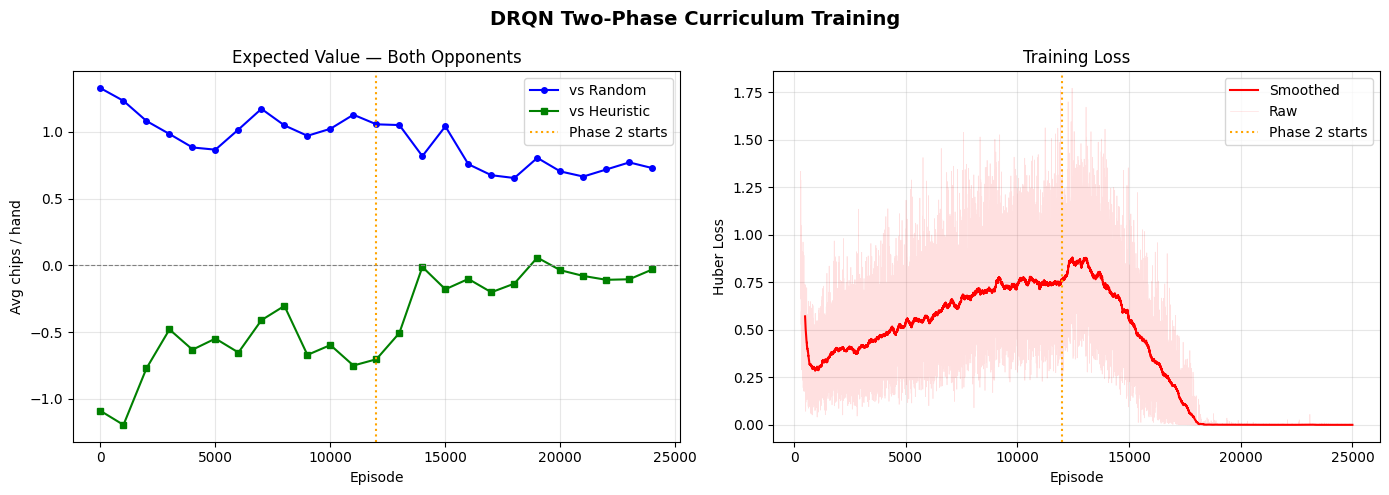

In [9]:
# DRQN training curves
plot_training_curves(
    ev_history_random=drqn_history['ev_random'],
    ev_history_heuristic=drqn_history['ev_heuristic'],
    loss_history=drqn_history['loss'],
    phase1_episodes=NUM_EPISODES_PHASE1,
    save_path=f'{PLOT_DIR}/drqn_training_curves.png'
)

## 10. Final Evaluation

In [10]:
print(f"\n{'='*60}")
print(f"FINAL EVALUATION ({NUM_EVAL_HANDS} hands per matchup)")
print(f"{'='*60}")

results = {}

# DRQN evaluations
print('\nDRQN vs ...')
ev_vs_random, traj_drqn_vs_random = evaluate_agents(
    env, agent_drqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
ev_vs_heuristic, traj_drqn_vs_heuristic = evaluate_agents(
    env, agent_drqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)
ev_vs_dqn, traj_drqn_vs_dqn = evaluate_agents(
    env, agent_drqn, agent_dqn, NUM_EVAL_HANDS, 'Standard DQN'
)

# DQN evaluations
print('\nDQN vs ...')
dqn_vs_random, traj_dqn_vs_random = evaluate_agents(
    env, agent_dqn, agent_random, NUM_EVAL_HANDS, 'Random'
)
dqn_vs_heuristic, traj_dqn_vs_heuristic = evaluate_agents(
    env, agent_dqn, agent_heuristic, NUM_EVAL_HANDS, 'Heuristic'
)

# Store results
results['DRQN vs Random'] = {
    'ev': ev_vs_random,
    'action_stats': compute_action_distribution(traj_drqn_vs_random, ACTION_NAMES)
}
results['DRQN vs Heuristic'] = {
    'ev': ev_vs_heuristic,
    'action_stats': compute_action_distribution(traj_drqn_vs_heuristic, ACTION_NAMES)
}
results['DRQN vs DQN'] = {
    'ev': ev_vs_dqn,
    'action_stats': compute_action_distribution(traj_drqn_vs_dqn, ACTION_NAMES)
}
results['DQN vs Random'] = {
    'ev': dqn_vs_random
}
results['DQN vs Heuristic'] = {
    'ev': dqn_vs_heuristic
}


FINAL EVALUATION (1000 hands per matchup)

DRQN vs ...
  Random                        : +0.754 chips/hand
  Heuristic                     : +0.009 chips/hand
  Standard DQN                  : +0.096 chips/hand

DQN vs ...
  Random                        : +0.638 chips/hand
  Heuristic                     : +0.208 chips/hand


## 11. Detailed Analysis

In [11]:
# Print detailed analysis
print("\n" + "="*60)
print("DETAILED ANALYSIS")
print("="*60)

for matchup, metrics in results.items():
    if 'action_stats' in metrics:
        print(f"\n{matchup}:")
        print(f"  EV: {metrics['ev']:+.3f} chips/hand")
        stats = metrics['action_stats']
        print(f"  Bluff Rate: {stats['bluff_rate']:.1f}% "
              f"({stats['bluff_attempts']}/{stats['total_jack_steps']} Jack decisions)")

        # Action distribution
        print(f"  Actions:")
        for action, count in sorted(stats['action_counts'].items(), key=lambda x: -x[1]):
            pct = 100 * count / stats['total_actions'] if stats['total_actions'] else 0
            print(f"    {action}: {pct:.1f}%")

# Final verdict
print("\n" + "="*60)
if ev_vs_dqn > 0:
    print("✓ SUCCESS: DRQN outperforms the memoryless DQN!")
    print(f"  DRQN advantage: {ev_vs_dqn:+.3f} chips/hand")
else:
    print("⚠ NOTE: DQN held its ground — consider more training episodes.")
print("="*60)


DETAILED ANALYSIS

DRQN vs Random:
  EV: +0.754 chips/hand
  Bluff Rate: 27.6% (201/729 Jack decisions)
  Actions:
    Raise: 36.9%
    Call: 33.3%
    Fold: 19.8%
    Check: 10.0%

DRQN vs Heuristic:
  EV: +0.009 chips/hand
  Bluff Rate: 23.3% (216/929 Jack decisions)
  Actions:
    Fold: 45.1%
    Raise: 40.2%
    Call: 10.1%
    Check: 4.6%

DRQN vs DQN:
  EV: +0.096 chips/hand
  Bluff Rate: 31.5% (327/1039 Jack decisions)
  Actions:
    Raise: 37.5%
    Fold: 29.5%
    Call: 16.9%
    Check: 16.1%

✓ SUCCESS: DRQN outperforms the memoryless DQN!
  DRQN advantage: +0.096 chips/hand


## 12. Final Comparison Plot

Saved EV comparison to /content/DLPW/outputs/plots/ev_comparison.png


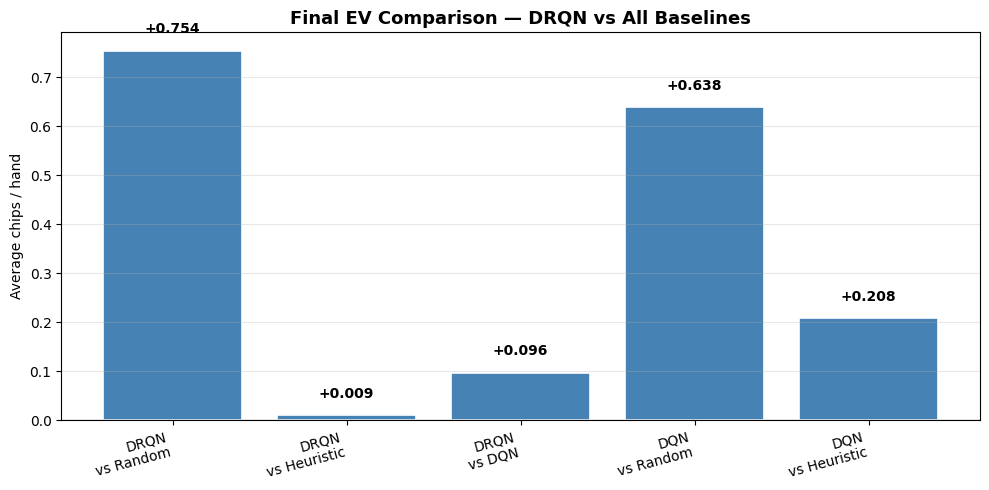

In [12]:
# EV comparison bar chart
ev_comparison = {
    'DRQN\nvs Random': results['DRQN vs Random']['ev'],
    'DRQN\nvs Heuristic': results['DRQN vs Heuristic']['ev'],
    'DRQN\nvs DQN': results['DRQN vs DQN']['ev'],
    'DQN\nvs Random': results['DQN vs Random']['ev'],
    'DQN\nvs Heuristic': results['DQN vs Heuristic']['ev'],
}
plot_ev_comparison_bar(
    results=ev_comparison,
    save_path=f'{PLOT_DIR}/ev_comparison.png'
)

## 13. Download Results

In [13]:
# Zip outputs for download
!zip -r /content/dlpw_outputs.zip {OUTPUT_DIR}

# Download
from google.colab import files
files.download('/content/dlpw_outputs.zip')

print("✓ Results zipped and ready for download")

  adding: content/DLPW/outputs/ (stored 0%)
  adding: content/DLPW/outputs/models/ (stored 0%)
  adding: content/DLPW/outputs/models/drqn_final.pt (deflated 10%)
  adding: content/DLPW/outputs/plots/ (stored 0%)
  adding: content/DLPW/outputs/plots/ev_comparison.png (deflated 21%)
  adding: content/DLPW/outputs/plots/drqn_training_curves.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Results zipped and ready for download
